## Luật số lớn, Định lý giới hạn trung tâm và Ước lượng triển vọng cực đại

Notebook này trình bày ba định luật thống kê cơ bản áp dụng trên tập dữ liệu **Wine Quality**:

1. **Ước lượng Triển vọng Cực đại:** Chứng minh rằng trung bình mẫu $\bar{x}$ và ma trận hiệp phương sai $S$ chính là nghiệm MLE của phân phối chuẩn đa biến $N_p(\mu, \Sigma)$.
2. **Multivariate LLN:** Quan sát sự hội tụ của trung bình mẫu ($\bar{x}$) về trung bình quần thể ($\mu$) của tất cả các đặc trưng hóa học cùng lúc.
3. **CLT Comparison:** So sánh cách phân phối trung bình mẫu của các biến khác nhau tiến về phân phối chuẩn.

## Preprocessing

Các biến như `total sulfur dioxide` và `chlorides` có thang đo rất khác nhau, chúng ta nên chuẩn hóa dữ liệu hoặc vẽ tỉ lệ lỗi (%) để so sánh sự hội tụ

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import sys
import os

sys.path.append(os.path.abspath("..")) 
from source.utils import mean, variance, standard_deviation, covariance, correlation

sns.set_style("whitegrid")
np.random.seed(42)

df = pd.read_csv('../data/WineQT.csv', sep=',')
features = df.drop(columns=['quality', 'Id'])
var_list = features.columns.tolist()
n, p = features.shape

pop_means = {col: mean(features[col]) for col in features.columns}
pop_stds = {col: standard_deviation(features[col], is_population=True) for col in features.columns}
pop_vars = {col: variance(features[col], is_population=True) for col in var_list}

print(f"Dataset: {n} mẫu, {p} biến đặc trưng")
print()

results_df = pd.DataFrame({
    'Variable': features.columns,
    'Population Mean': [pop_means[col] for col in features.columns],
    'Population Std Dev': [pop_stds[col] for col in features.columns]
})

print("Trung bình quần thể của các biến:")
print(results_df[['Variable', 'Population Mean']])

print("\nĐộ lệch chuẩn quần thể của các biến:")
print(results_df[['Variable', 'Population Std Dev']])

Dataset: 1143 mẫu, 11 biến đặc trưng

Trung bình quần thể của các biến:
                Variable  Population Mean
0          fixed acidity         8.311111
1       volatile acidity         0.531339
2            citric acid         0.268364
3         residual sugar         2.532152
4              chlorides         0.086933
5    free sulfur dioxide        15.615486
6   total sulfur dioxide        45.914698
7                density         0.996730
8                     pH         3.311015
9              sulphates         0.657708
10               alcohol        10.442111

Độ lệch chuẩn quần thể của các biến:
                Variable  Population Std Dev
0          fixed acidity            1.746830
1       volatile acidity            0.179555
2            citric acid            0.196600
3         residual sugar            1.355324
4              chlorides            0.047247
5    free sulfur dioxide           10.246001
6   total sulfur dioxide           32.767787
7                density  

## Luật số lớn - So sánh tốc độ hội tụ
Chúng ta sẽ tính toán sai số tương đối (Relative Error) giữa $\bar{x}$ và $\mu$ khi $n$ tăng dần:
$$Error = \frac{|\bar{x} - \mu|}{\mu}$$

In [4]:
np.random.seed(42)  
sizes = np.arange(10, 1001, 10)

results_lln = {v: [] for v in features.columns}
for n in sizes:
    idx = np.random.choice(len(features), size=n, replace=False)
    sample = features.iloc[idx]
    for col in features.columns:
        err = abs(mean(sample[col]) - pop_means[col]) / pop_means[col]
        results_lln[col].append(err)

# Bảng sai số tại các mốc n
milestones = [50, 100, 200, 500, 1000]
milestone_data = {}
for ms in milestones:
    idx_ms = np.searchsorted(sizes, ms)
    milestone_data[f'n={ms}'] = [
        round(results_lln[col][min(idx_ms, len(results_lln[col])-1)], 4)
        for col in var_list
    ]

print("LLN simulation completed.")
print(f"Sample size: {sizes[0]} -> {sizes[-1]}")

error_table = pd.DataFrame(milestone_data, index=var_list)
print("Sai số tương đối tại các mốc cỡ mẫu:")
print(error_table.to_string())

LLN simulation completed.
Sample size: 10 -> 1000
Sai số tương đối tại các mốc cỡ mẫu:
                        n=50   n=100   n=200   n=500  n=1000
fixed acidity         0.0088  0.0323  0.0090  0.0110  0.0003
volatile acidity      0.0242  0.0376  0.0113  0.0001  0.0014
citric acid           0.0225  0.0181  0.0245  0.0238  0.0051
residual sugar        0.0640  0.0088  0.0029  0.0243  0.0116
chlorides             0.0337  0.0056  0.0194  0.0077  0.0015
free sulfur dioxide   0.0246  0.1642  0.0156  0.0370  0.0048
total sulfur dioxide  0.2035  0.0099  0.0113  0.0151  0.0017
density               0.0001  0.0001  0.0002  0.0001  0.0000
pH                    0.0069  0.0049  0.0014  0.0008  0.0000
sulphates             0.0254  0.0006  0.0129  0.0131  0.0008
alcohol               0.0036  0.0014  0.0105  0.0043  0.0002


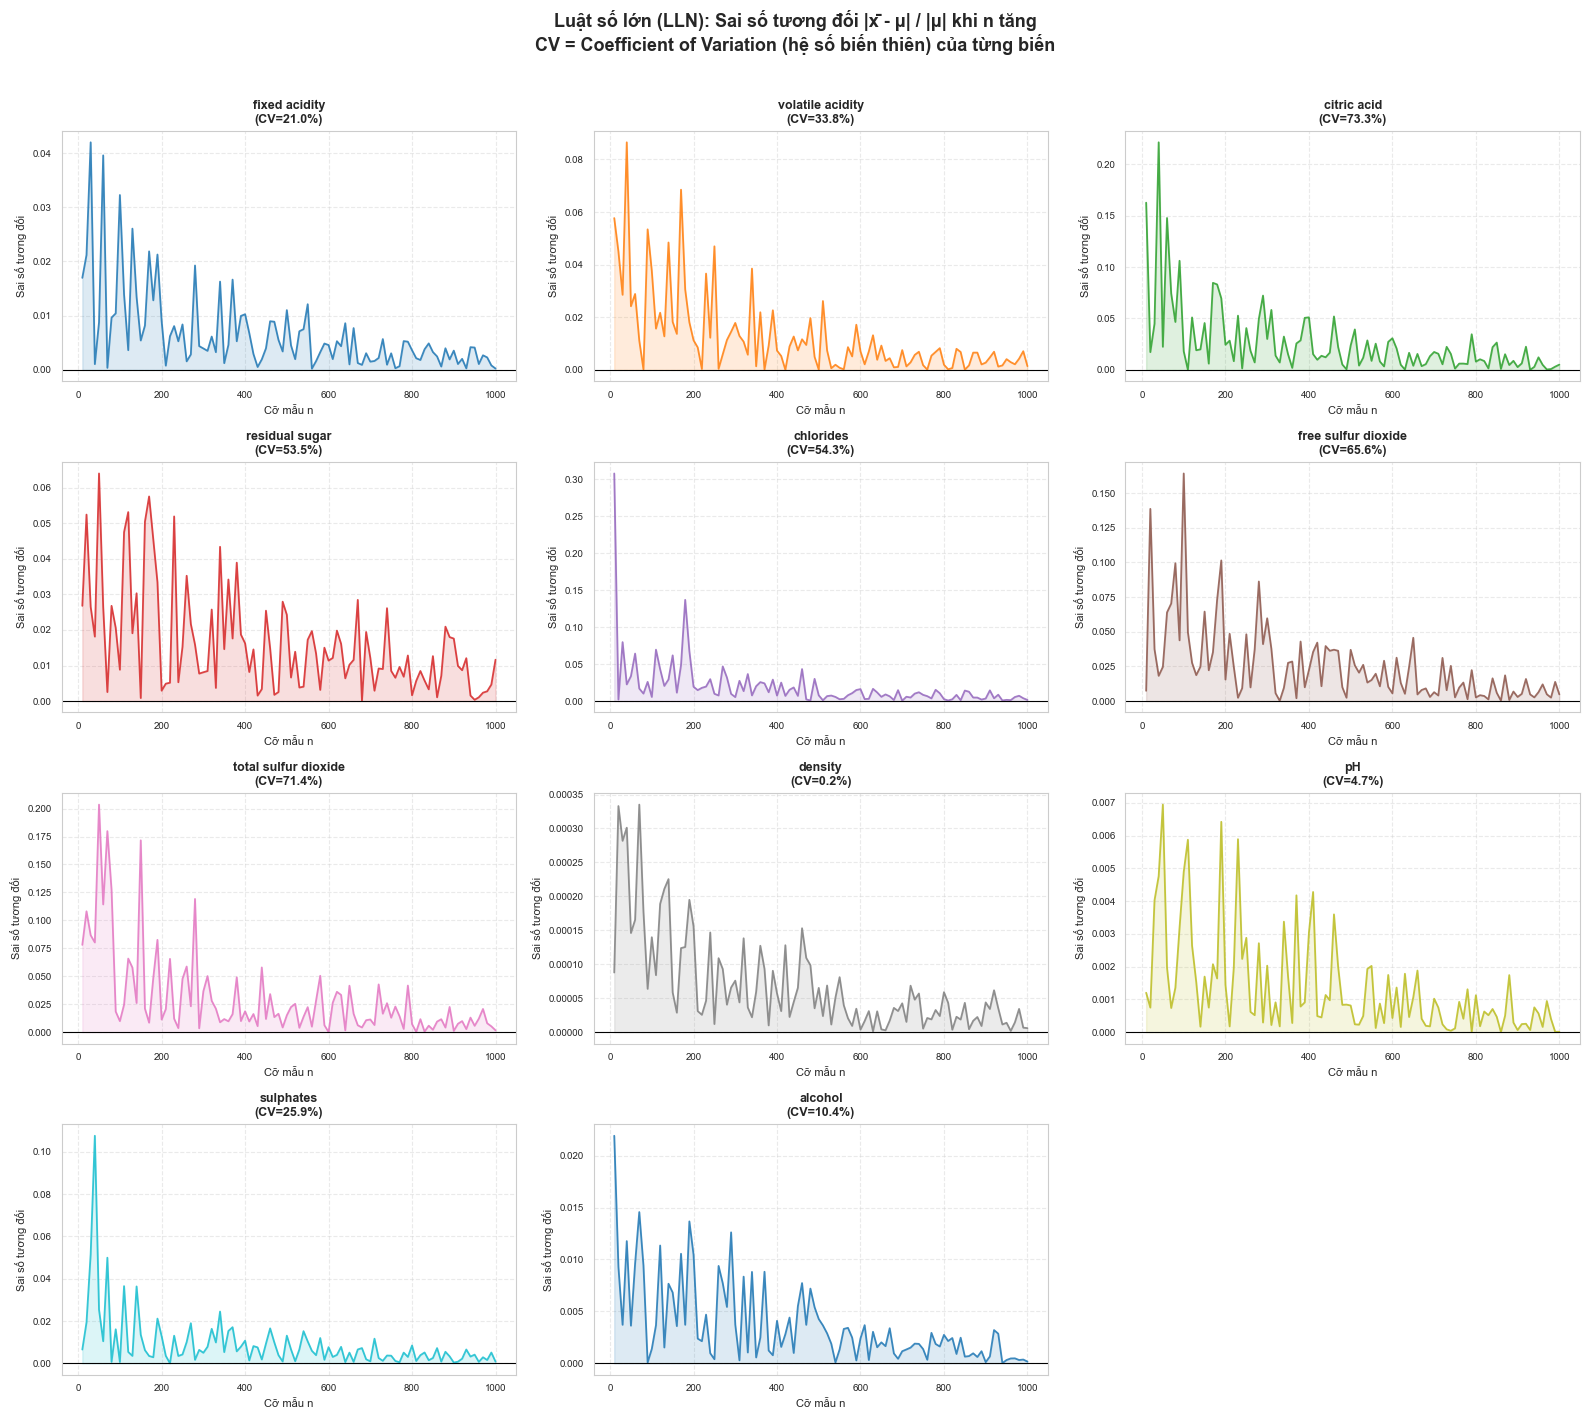

In [5]:
colors_all = sns.color_palette("tab10", len(var_list))

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, (col, color) in enumerate(zip(var_list, colors_all)):
    ax = axes[i]
    ax.plot(sizes, results_lln[col], color=color, lw=1.3, alpha=0.85)
    ax.fill_between(sizes, results_lln[col], alpha=0.15, color=color)
    ax.axhline(0, color='black', lw=0.8)

    cv = pop_stds[col] / abs(pop_means[col]) * 100
    ax.set_title(f'{col}\n(CV={cv:.1f}%)', fontsize=9, fontweight='bold')
    ax.set_xlabel('Cỡ mẫu n', fontsize=8)
    ax.set_ylabel('Sai số tương đối', fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.tick_params(labelsize=7)

# Tắt ô thừa
for j in range(len(var_list), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Luật số lớn (LLN): Sai số tương đối |x̄ - μ| / |μ| khi n tăng\n'
             'CV = Coefficient of Variation (hệ số biến thiên) của từng biến',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Nhận xét 

**Xu hướng chung**

Cả 11 biến đều thể hiện xu hướng sai số tương đối giảm dần về 0 khi n tăng. Tuy nhiên, đường hội tụ không đơn điệu giảm mà dao động lên xuống, đặc biệt rõ ở vùng n < 200. Điều này có thể giải thích vì đây là quá trình lấy mẫu ngẫu nhiên — LLN phát biểu về xác suất hội tụ chứ không đảm bảo mỗi bước đều tốt hơn bước trước.

**Phân nhóm tốc độ hội tụ theo CV**

Có thể chia 11 biến thành 3 nhóm rõ rệt dựa trên hệ số biến thiên CV:
- *Nhóm hội tụ nhanh (CV < 10%):* `density` (CV = 0.2%), `pH` (CV = 4.7%), `alcohol` (CV = 10.4%) hội tụ gần như ngay lập tức — sai số tại $n=50$ đã rất nhỏ (0.0001, 0.0069, 0.0036). `density` đặc biệt ổn định vì các giá trị gần như không phân tán quanh trung bình 0.9967 g/mL.
- *Nhóm hội tụ trung bình (CV = 20–55%):* `fixed acidity` (21%), `sulphates` (25.9%), `volatile acidity` (33.8%), `residual sugar` (53.5%), `chlorides` (54.3%) cần khoảng $n=200–500$ để sai số xuống dưới 2%.
- *Nhóm hội tụ chậm (CV > 65%):* `citric acid` (73.3%), `total sulfur dioxide` (71.4%), `free sulfur dioxide` (65.6%) dao động mạnh nhất — `total sulfur dioxide` tại $n = 50$ có sai số lên tới 20.35%, tức trung bình mẫu lệch gần 9.4 đơn vị so với $\mu = 45.9$.

**Phân tích các kết quả bất thường**

Bảng số liệu cho thấy một số giá trị tăng đột biến tại các mốc nhất định:
- `free sulfur dioxide` tại $n=100$: sai số tăng vọt lên 16.42% dù ở $n=50$ chỉ là 2.46%. Đây là hệ quả của việc lấy mẫu ngẫu nhiên gặp phải một cụm outlier, biến này có phân phối lệch phải mạnh nên trung bình rất nhạy cảm với các giá trị cực đoan.
- `total sulfur dioxide` tại $n=50$: sai số 20.35% là *lớn nhất* toàn bảng, phản ánh CV cao nhất (71.4%) và phân phối có đuôi dài.
- Ngược lại, `density` và `pH` duy trì sai số dưới 0.07% ở mọi mốc, hai biến này có thể được ước lượng chính xác ngay cả với mẫu rất nhỏ.

**Ý nghĩa thực tiễn**

Từ kết quả LLN, ta rút ra một số quyết định cụ thể cho bài toán phân tích rượu vang. Với mục tiêu sai số dưới 5% cho tất cả các biến, cần ít nhất $n \approx 500 - 1000$ mẫu. Tại $n=1000$, sai số lớn nhất chỉ là 1.16% (`residual sugar`), đạt yêu cầu. Nếu chỉ quan tâm đến các biến vật lý ổn định như `density`, `pH`, `alcohol`, thì $n=50–100$ đã đủ tin cậy. Đặc biệt cần thận trọng khi ước lượng trung bình của `total sulfur dioxide` và `free sulfur dioxide` từ mẫu nhỏ vì hai biến này dễ bị kéo lệch bởi outlier — phân phối của chúng có đuôi dài, cần mẫu lớn hơn để trung hòa ảnh hưởng các điểm cực đoan theo LLN.


## Định luật giới hạn trung tâm

In [6]:
np.random.seed(42)
n_size = 50
n_trials = 1000

results_clt = {v: [] for v in features.columns}
for _ in range(n_trials):
    idx = np.random.choice(len(features), size=n_size, replace=True)
    sample = features.iloc[idx]
    for col in features.columns:
        results_clt[col].append(mean(sample[col]))

print(f"CLT: {n_trials} lần lấy mẫu với kích thước n={n_size}.")

for col in features.columns:
    emp_mean = np.mean(results_clt[col])
    emp_std = np.std(results_clt[col])
    theory_std = pop_stds[col] / np.sqrt(n_size)
    print(f"  {col:25s}  μ_emp={emp_mean:.4f}  σ_emp={emp_std:.4f}  σ_theory={theory_std:.4f}")

CLT: 1000 lần lấy mẫu với kích thước n=50.
  fixed acidity              μ_emp=8.3073  σ_emp=0.2495  σ_theory=0.2470
  volatile acidity           μ_emp=0.5342  σ_emp=0.0252  σ_theory=0.0254
  citric acid                μ_emp=0.2665  σ_emp=0.0280  σ_theory=0.0278
  residual sugar             μ_emp=2.5385  σ_emp=0.1925  σ_theory=0.1917
  chlorides                  μ_emp=0.0868  σ_emp=0.0066  σ_theory=0.0067
  free sulfur dioxide        μ_emp=15.5724  σ_emp=1.3974  σ_theory=1.4490
  total sulfur dioxide       μ_emp=45.8914  σ_emp=4.6340  σ_theory=4.6341
  density                    μ_emp=0.9967  σ_emp=0.0003  σ_theory=0.0003
  pH                         μ_emp=3.3115  σ_emp=0.0226  σ_theory=0.0221
  sulphates                  μ_emp=0.6563  σ_emp=0.0233  σ_theory=0.0241
  alcohol                    μ_emp=10.4332  σ_emp=0.1493  σ_theory=0.1530


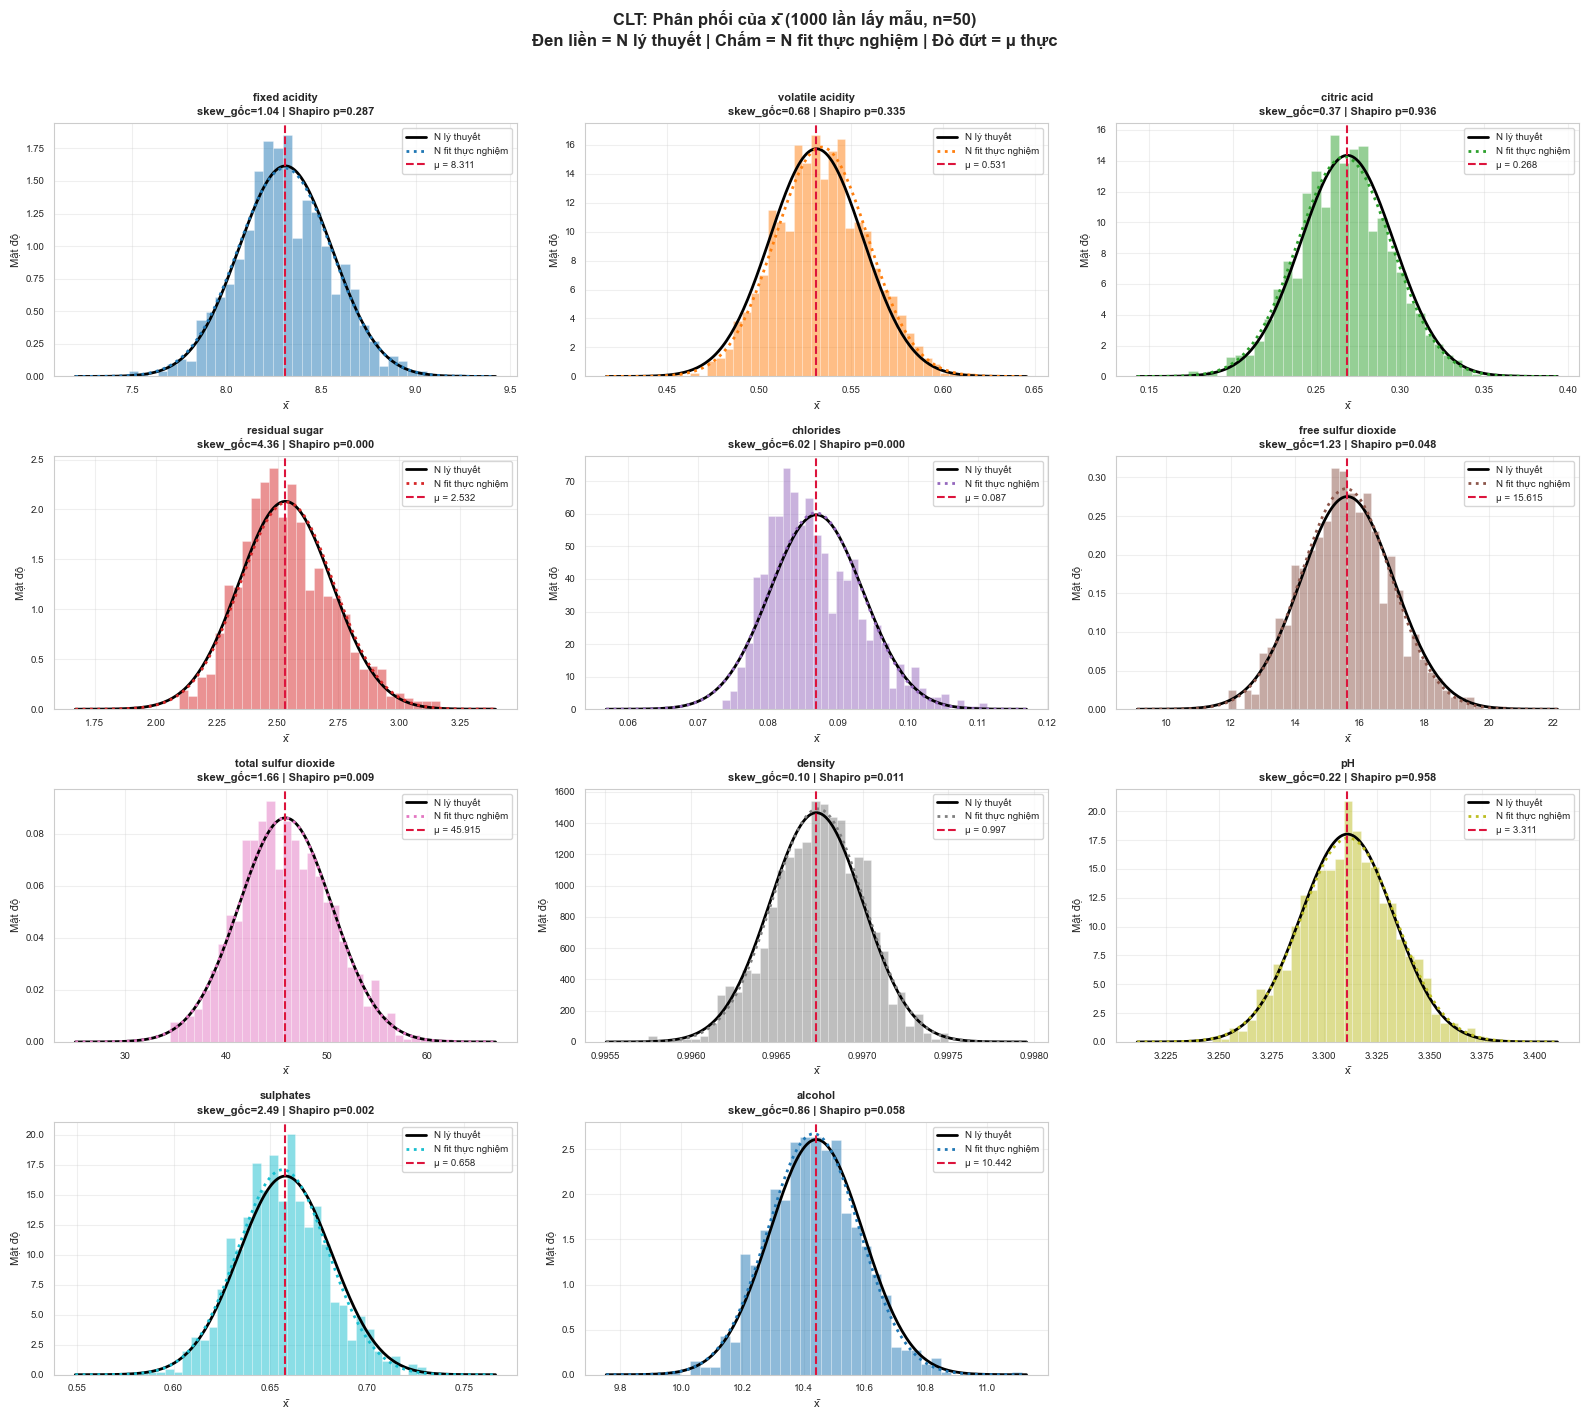

In [7]:
colors_clt = sns.color_palette("tab10", len(var_list))

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, (col, color) in enumerate(zip(var_list, colors_clt)):
    ax = axes[i]
    data       = results_clt[col]
    mu_col     = pop_means[col]
    theory_std = pop_stds[col] / np.sqrt(n_size)
    emp_std    = np.std(data)
    _, p_val   = stats.shapiro(data)

    ax.hist(data, bins=35, density=True, color=color, alpha=0.5,
            edgecolor='white', linewidth=0.4)

    x_rng = np.linspace(mu_col - 4.5*theory_std, mu_col + 4.5*theory_std, 200)
    ax.plot(x_rng, stats.norm.pdf(x_rng, mu_col, theory_std),
            color='black', lw=2, label='N lý thuyết')
    ax.plot(x_rng, stats.norm.pdf(x_rng, np.mean(data), emp_std),
            color=color, lw=2, ls=':', label='N fit thực nghiệm')
    ax.axvline(mu_col, color='crimson', lw=1.5, ls='--',
               label=f'μ = {mu_col:.3f}')

    skew_orig = stats.skew(features[col])
    ax.set_title(f'{col}\nskew_gốc={skew_orig:.2f} | Shapiro p={p_val:.3f}',
                 fontsize=8, fontweight='bold')
    ax.set_xlabel('x̄', fontsize=8)
    ax.set_ylabel('Mật độ', fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)

for j in range(len(var_list), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'CLT: Phân phối của x̄ ({n_trials} lần lấy mẫu, n={n_size})\n'
             'Đen liền = N lý thuyết | Chấm = N fit thực nghiệm | Đỏ đứt = μ thực',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

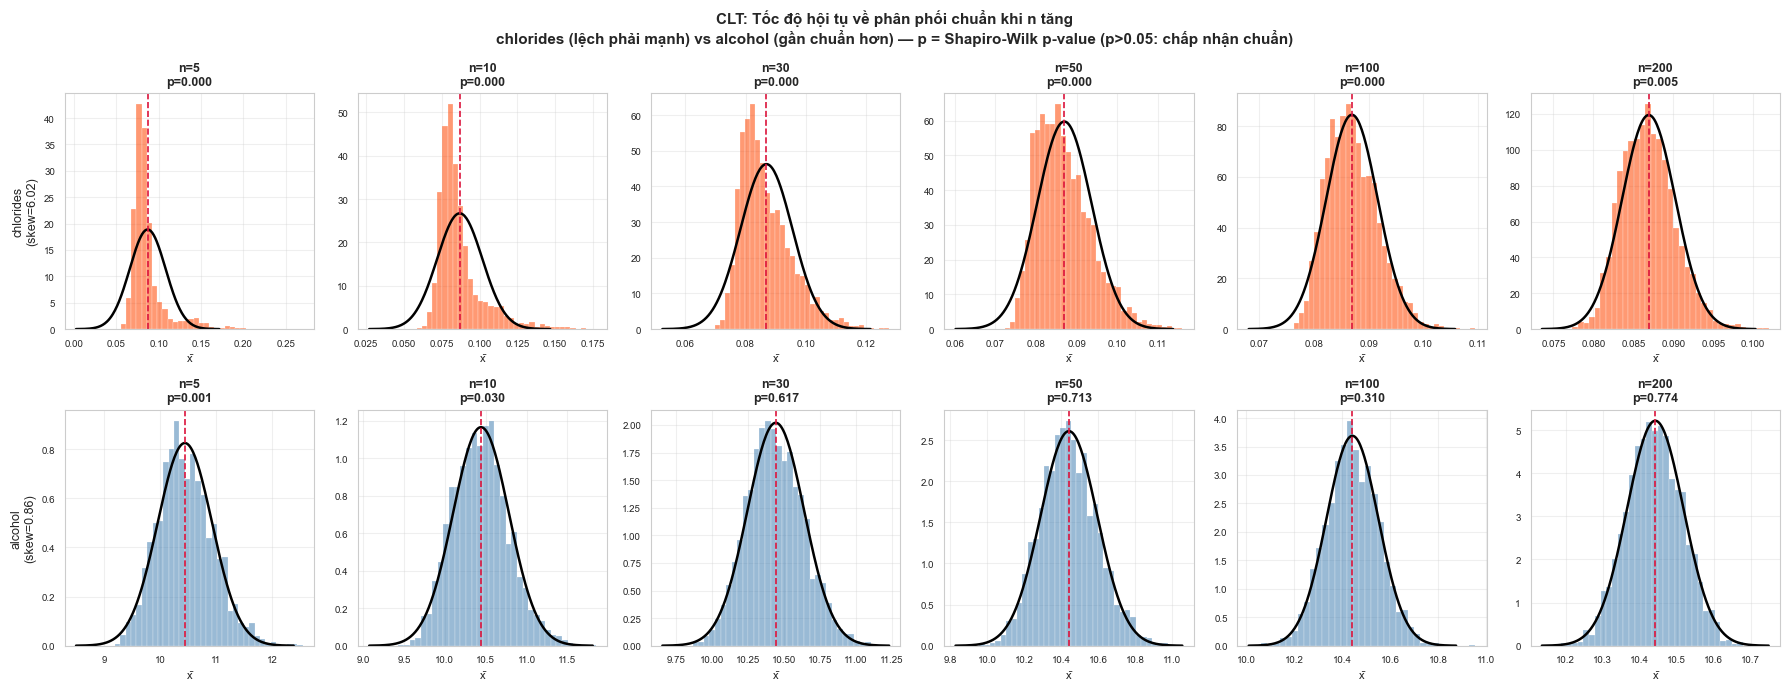

In [8]:
np.random.seed(42)
n_trials_conv = 3000
n_sizes_conv  = [5, 10, 30, 50, 100, 200]
focus_vars    = ['chlorides', 'alcohol']

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
pal_conv = {'chlorides': 'orangered', 'alcohol': 'steelblue'}

for row, col in enumerate(focus_vars):
    mu_col  = pop_means[col]
    std_col = pop_stds[col]
    skew_original = stats.skew(features[col])

    for c_idx, sz in enumerate(n_sizes_conv):
        ax = axes[row, c_idx]
        samples_means = [
            features[col].sample(sz, replace=True).mean()
            for _ in range(n_trials_conv)
        ]
        theory_std = std_col / np.sqrt(sz)
        _, p_val   = stats.shapiro(samples_means[:500])  # Shapiro giới hạn 5000 pts

        ax.hist(samples_means, bins=35, density=True,
                color=pal_conv[col], alpha=0.55, edgecolor='white', lw=0.3)
        x_rng = np.linspace(mu_col - 4*theory_std, mu_col + 4*theory_std, 200)
        ax.plot(x_rng, stats.norm.pdf(x_rng, mu_col, theory_std),
                color='black', lw=1.8)
        ax.axvline(mu_col, color='crimson', lw=1.2, ls='--')

        ax.set_title(f'n={sz}\np={p_val:.3f}', fontsize=9, fontweight='bold')
        ax.set_xlabel('x̄', fontsize=8)
        if c_idx == 0:
            ax.set_ylabel(f'{col}\n(skew={skew_original:.2f})', fontsize=9)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3)

plt.suptitle('CLT: Tốc độ hội tụ về phân phối chuẩn khi n tăng\n'
             'chlorides (lệch phải mạnh) vs alcohol (gần chuẩn hơn) — '
             'p = Shapiro-Wilk p-value (p>0.05: chấp nhận chuẩn)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

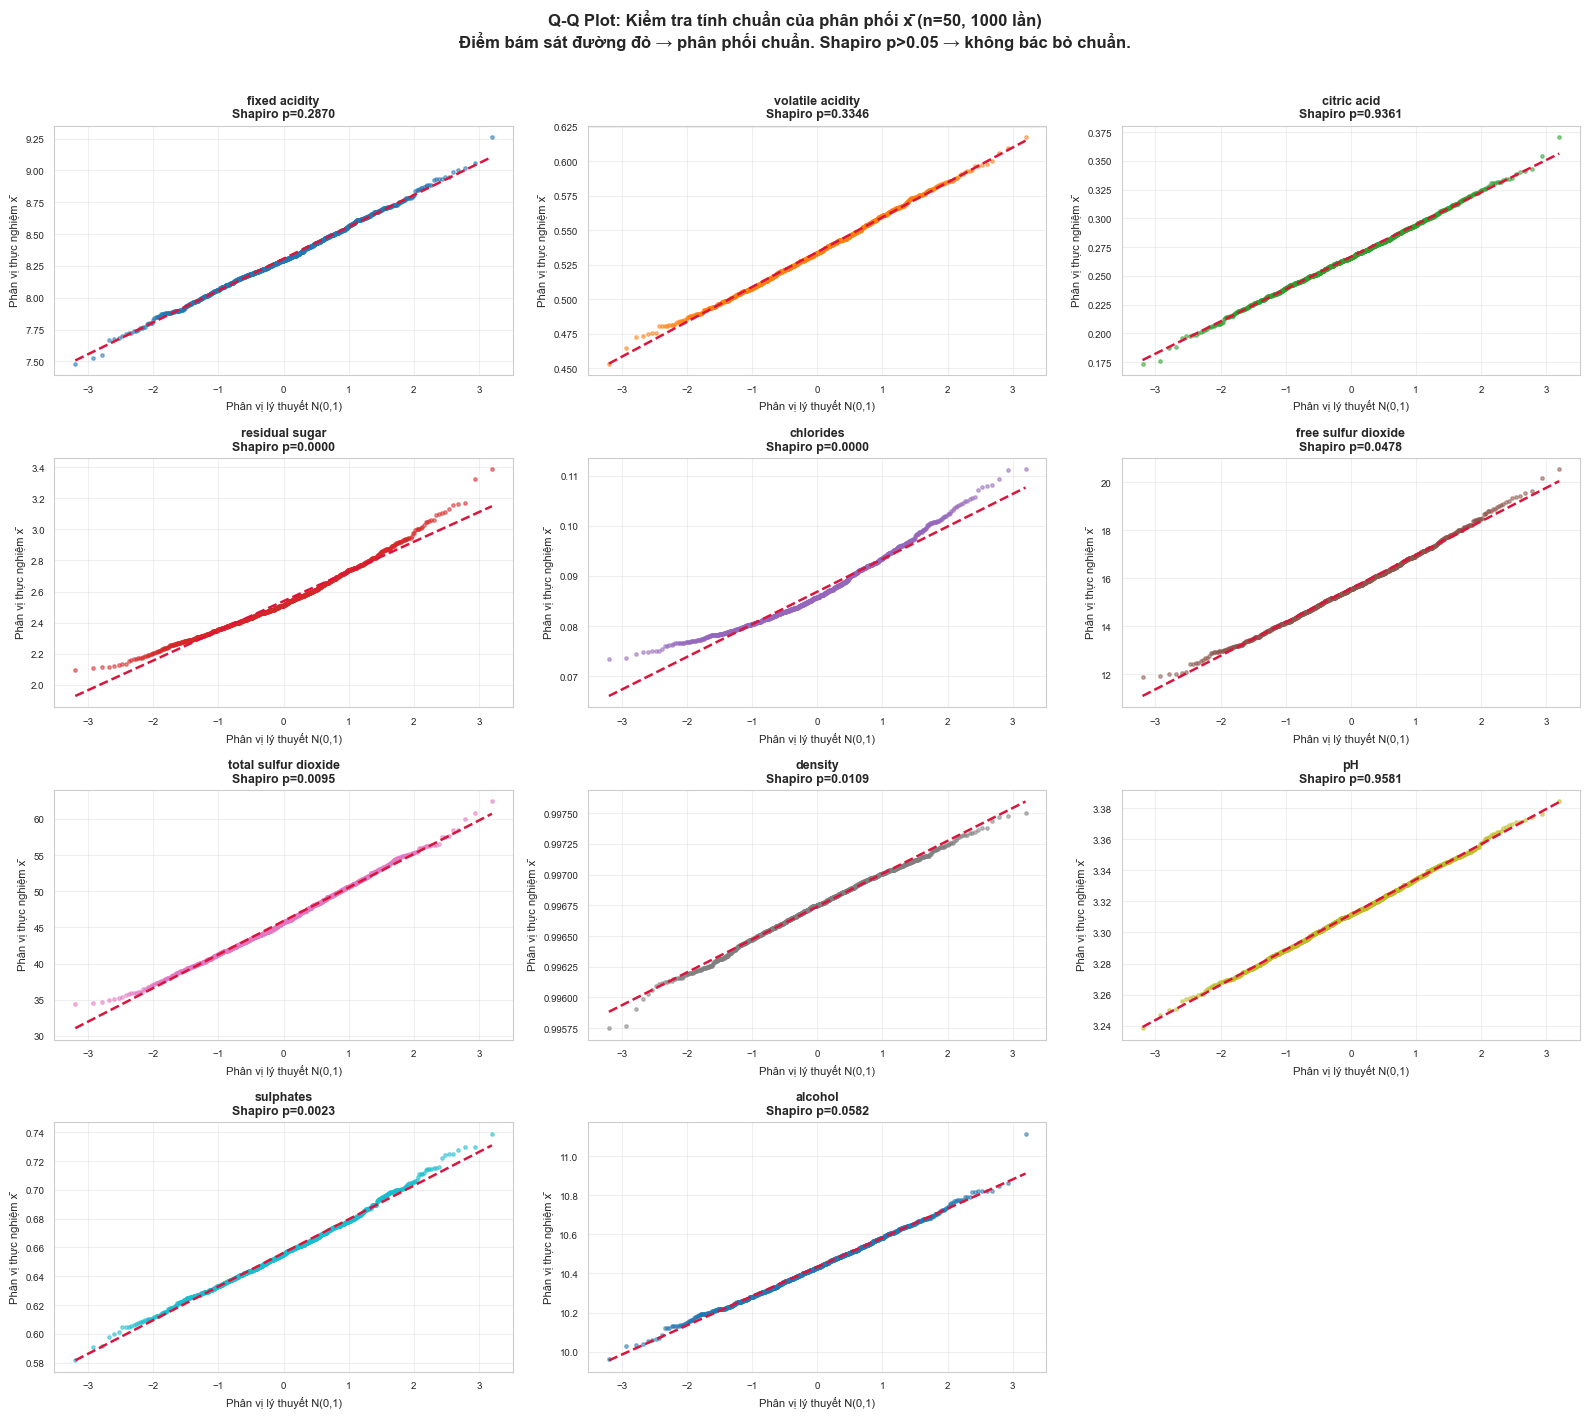

In [9]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, (col, color) in enumerate(zip(var_list, colors_clt)):
    ax = axes[i]
    data = results_clt[col]

    # Q-Q plot
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
    ax.scatter(osm, osr, color=color, s=6, alpha=0.5)
    x_line = np.array([osm[0], osm[-1]])
    ax.plot(x_line, slope * x_line + intercept, color='crimson', lw=1.8, ls='--')

    _, p_val = stats.shapiro(data)
    ax.set_title(f'{col}\nShapiro p={p_val:.4f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Phân vị lý thuyết N(0,1)', fontsize=8)
    ax.set_ylabel('Phân vị thực nghiệm x̄', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)

for j in range(len(var_list), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Q-Q Plot: Kiểm tra tính chuẩn của phân phối x̄ (n={n_size}, {n_trials} lần)\n'
             'Điểm bám sát đường đỏ → phân phối chuẩn. Shapiro p>0.05 → không bác bỏ chuẩn.',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Nhận xét

**Phân tích Histogram**
- *Xấp xỉ chuẩn tốt (Shapiro p > 0.05):* `fixed acidity` (p=0.287), `volatile acidity` (p=0.335), `citric acid` (p=0.936), `pH` (p=0.958), `alcohol` (p=0.058). Histogram bám sát đường cong lý thuyết, đường fit thực nghiệm gần như trùng với N lý thuyết va hội tụ hoàn toàn tại $n=50$.
- *Xấp xỉ chuẩn biên (p gần 0.05):* `free sulfur dioxide` (p=0.048), `alcohol` (p=0.058). Histogram có hình dạng chuẩn về tổng thể nhưng phần đuôi phải còn hơi phình — phân phối gốc lệch phải (skew=1.23) chưa phẳng hoàn toàn ở $n=50$.
- *Chưa đạt chuẩn (p < 0.01):* `residual sugar` (p=0.000, skew_gốc=4.36), `chlorides` (p=0.000, skew_gốc=6.02), `sulphates` (p=0.002), `total sulfur dioxide` (p=0.009), `density` (p=0.011). Đây đều là các biến có phân phối gốc lệch phải rất mạnh — $n=50$ chưa đủ lớn để triệt tiêu ảnh hưởng của skewness. Đặc biệt chlorides với skew=6.02 là trường hợp cực đoan nhất.

Hình 2 minh họa trực quan sự tương phản giữa hai biến `chlorides` vs `alcohol`
- `alcohol` (skew=0.86) đạt chuẩn từ rất sớm — tại $n=30$, $p=0.617$, histogram đã khớp tốt với đường cong lý thuyết. Biến này gần đối xứng nên CLT hội tụ nhanh.
- Ngược lại `chlorides` (skew=6.02) là trường hợp đáng chú ý — ngay cả tại $n=200$, $p$ vẫn chỉ đạt 0.005, histogram còn lệch rõ so với đường chuẩn. Điều này cho thấy với phân phối có đuôi nặng và lệch mạnh, với $n \geq 30$ không đủ — cần n lớn hơn nhiều. Đây là bằng chứng thực nghiệm cho thấy CLT đảm bảo hội tụ khi $n \to \infty$ nhưng tốc độ hội tụ phụ thuộc vào hình dạng phân phối gốc.

**Phân tích Q-Q Plot**

Q-Q plot cung cấp thêm thông tin mà histogram bỏ qua — đặc biệt ở vùng đuôi:
- `citric acid`, `volatile acidity`, `pH`, `fixed acidity`: Điểm bám đường đỏ gần như hoàn hảo từ đuôi trái đến đuôi phải $\rightarrow$ phân phối $\bar{X}$ đạt chuẩn ở cả phần trung tâm lẫn đuôi.
- `residual sugar`, `chlorides`: Q-Q plot cong lên ở đuôi phải — dấu hiệu của phân phối lệch phải, đuôi phải dày hơn chuẩn. Tuy histogram trông gần chuẩn nhưng Q-Q plot phát hiện được sự lệch ẩn này.
- `density` ($p=0.011$): CV rất nhỏ (0.2%) nhưng Q-Q plot lại cong nhẹ — nguyên nhân là phân phối gốc của `density` có hai đỉnh do sự tồn tại của hai nhóm rượu có hàm lượng đường khác nhau, khiến $\bar{X}$ dù thu hẹp nhưng vẫn chưa hoàn toàn chuẩn tại $n=50$.

**Nhận xét tổng hợp và quyết định thực tiễn**

Kết quả CLT trên tập Wine Quality dẫn đến một số kết luận quan trọng, không có một ngưỡng $n$ duy nhất — ta cần khoảng $n \geq 30$ cho các biến gần chuẩn (`alcohol`, `pH`), $n \geq 100 - 200$ cho biến lệch trung bình (`sulphates`, `total sulfur dioxide`), và $n \geq 500$ cho biến lệch lớn (`chlorides`, `residual sugar`).

> Nếu muốn xây dựng khoảng tin cậy hoặc kiểm định giả thuyết về trung bình `alcohol`, `pH`, `citric acid` thì $n=50$ là đủ và kết quả đáng tin cậy. Với `chlorides` hoặc `residual sugar`, cần thận trọng hơn — ta nên dùng bootstrap confidence interval thay vì khoảng tin cậy chuẩn khi mẫu nhỏ.